In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [16]:

df = pd.read_csv(r"c:\Users\Huawei\OneDrive\Desktop\projects\EDA-s\train_data.csv")
print(df.shape)
df.head()

(7831, 3)


,Tweet_ID,Tweet,Label
0,1,#الرياض #أمطار_الرياض #السعودية #مطر #الرياض_ت...,OBJ
1,2,من بين الأسماء محمود القرش، مصر الجديدة وآخرين...,OBJ
2,3,مقتل طفلة لبنانية في تبادل إطلاق نار بين علويي...,OBJ
3,4,#الروح_و_الجسد #مصطفي_محمود,OBJ
4,5,دعبد المنعم أبو الفتوح فى عيون العالم,OBJ


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7831 entries, 0 to 7830
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Tweet_ID  7831 non-null   int64 
 1   Tweet     7831 non-null   object
 2   Label     7831 non-null   object
dtypes: int64(1), object(2)
memory usage: 183.7+ KB


In [18]:
print("\nMissing values:\n", df.isnull().sum())




Missing values:
 Tweet_ID    0
Tweet       0
Label       0
dtype: int64


In [19]:
df["Label"].value_counts()



Label
OBJ        5233
NEG        1317
NEUTRAL     654
POS         627
Name: count, dtype: int64

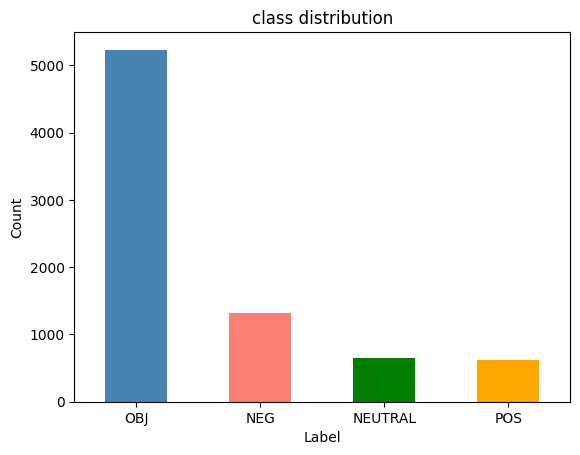

In [20]:
df["Label"].value_counts().plot(kind="bar", color=["steelblue","salmon","green","orange"])
plt.title("class distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


### Tweet length

In [21]:
# tweet length
df["tweet_length"] = df["Tweet"].apply(len)

# average tweet length by label
df.groupby("Label")["tweet_length"].mean().round(0)


Label
NEG         93.0
NEUTRAL    103.0
OBJ         79.0
POS         77.0
Name: tweet_length, dtype: float64

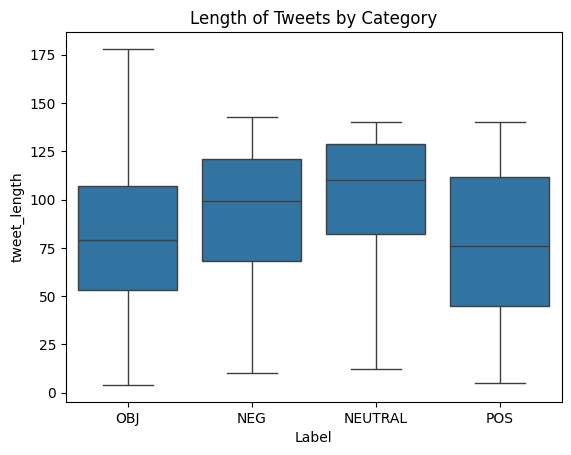

In [22]:
# boxplot of tweet length by label
sns.boxplot(x="Label", y="tweet_length", data=df)
plt.title("Length of Tweets by Category")
plt.show()


In [23]:
from collections import Counter

for label in df["Label"].unique():
    tweets = " ".join(df[df["Label"] == label]["Tweet"])
    words = tweets.split()
    common = Counter(words).most_common(10)
    print(f"\n--- {label} ---")
    for word, count in common:
        print(f"{word}: {count}")



--- OBJ ---
في: 1288
من: 1160
على: 850
و: 692
-: 481
#: 477
فى: 341
عن: 326
مع: 324
…: 321

--- NEG ---
من: 400
في: 362
على: 262
و: 195
فى: 150
لا: 134
عن: 115
مصر: 111
ما: 98
كل: 95

--- NEUTRAL ---
من: 230
في: 194
و: 123
على: 121
لا: 78
ان: 74
عن: 57
مع: 53
مصر: 48
كل: 48

--- POS ---
في: 176
من: 152
و: 116
الله: 90
على: 87
يا: 53
كل: 44
فى: 43
مصر: 42
لا: 39


In [24]:
!pip install camel-tools



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Huawei\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [25]:
import re
from collections import Counter

# stopwords عربية بسيطة
stopwords = set([
    "في","من","على","و","عن","مع","إلى","هذا","هذه","التي","الذي",
    "كان","لا","ما","كل","قد","أن","إن","لم","عند","حتى","أو","كما",
    "هو","هي","هم","نحن","أنا","لي","له","لها","بعد","قبل","حين","ثم"
])

def clean_text(text):
    text = re.sub(r"http\S+|#\S+|@\S+|[^\w\s]|[a-zA-Z]|\d", " ", str(text))
    words = text.split()
    return [w for w in words if w not in stopwords and len(w) > 2]

for label in ["OBJ", "NEG", "NEUTRAL", "POS"]:
    words = []
    for tweet in df[df["Label"] == label]["Tweet"]:
        words.extend(clean_text(tweet))
    common = Counter(words).most_common(10)
    print(f"\n--- {label} ---")
    for word, count in common:
        print(f"{word}: {count}")



--- OBJ ---
مصر: 260
الله: 246
اليوم: 205
كلام: 199
آخر: 196
شاهد: 187
اللي: 145
عمرو: 133
عبد: 127
الفتوح: 123

--- NEG ---
مصر: 113
الانقلاب: 74
اللي: 71
مرسي: 68
الاخوان: 59
ولا: 55
الى: 48
الإخوان: 43
اليوم: 37
الناس: 35

--- NEUTRAL ---
مصر: 48
مرسي: 45
اللي: 41
ولا: 36
الله: 36
الشعب: 35
الثورة: 34
الانقلاب: 28
الاخوان: 26
الإخوان: 26

--- POS ---
الله: 92
مصر: 44
اللي: 22
الشعب: 22
اليوم: 22
ولا: 21
يوم: 18
جدا: 16
بين: 15
الثورة: 14


### data are immbalanced to eagybt

In [26]:
!pip install wordcloud arabic-reshaper python-bidi



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: C:\Users\Huawei\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


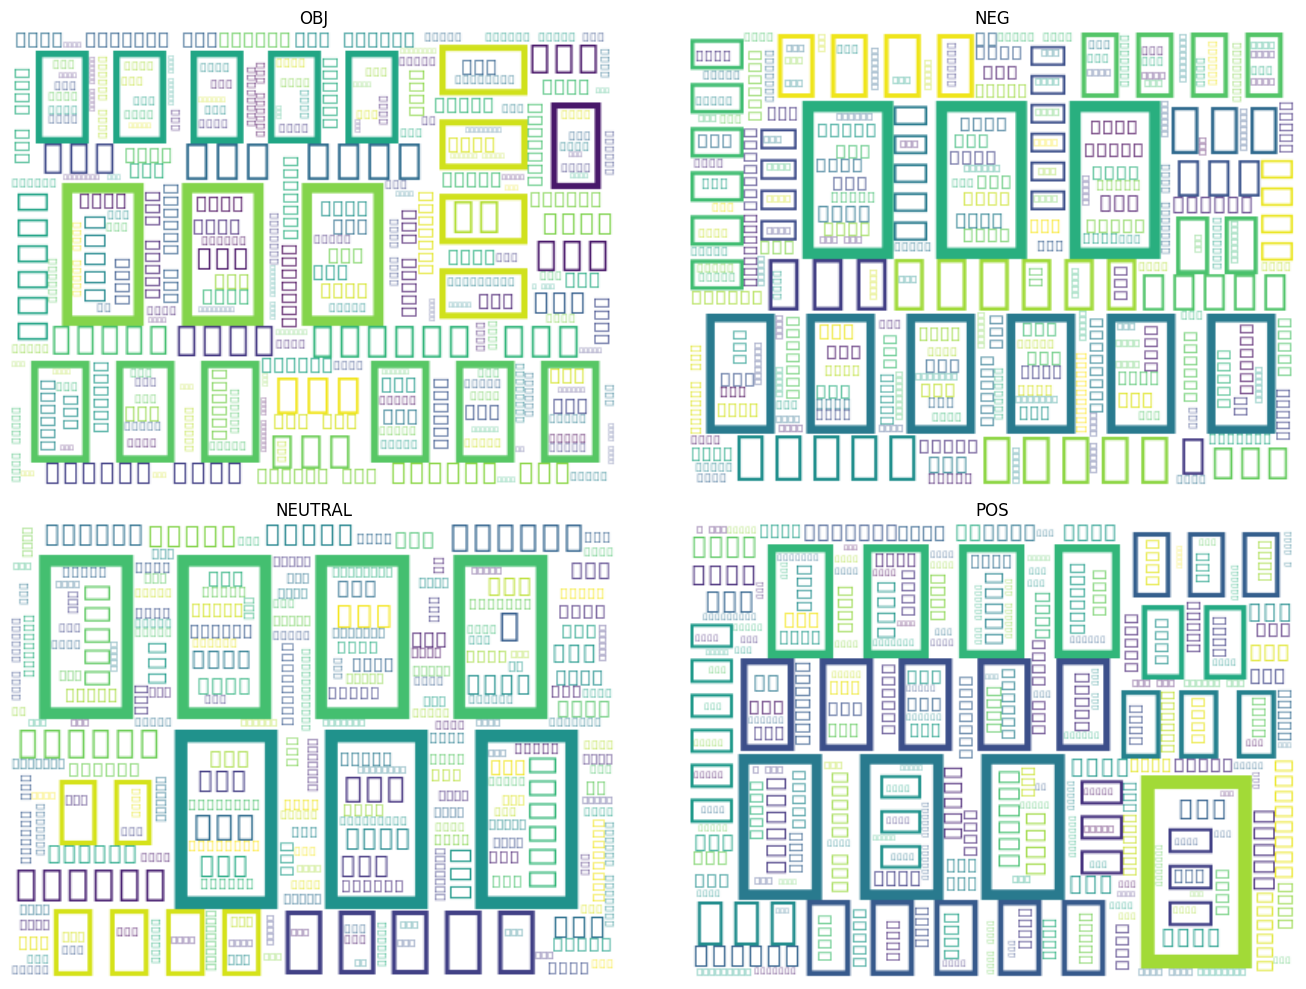

In [27]:
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, label in zip(axes.flatten(), ["OBJ", "NEG", "NEUTRAL", "POS"]):
    words = []
    for tweet in df[df["Label"] == label]["Tweet"]:
        words.extend(clean_text(tweet))
    text = " ".join(words)
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    wc = WordCloud(width=400, height=300, background_color="white").generate(bidi_text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()


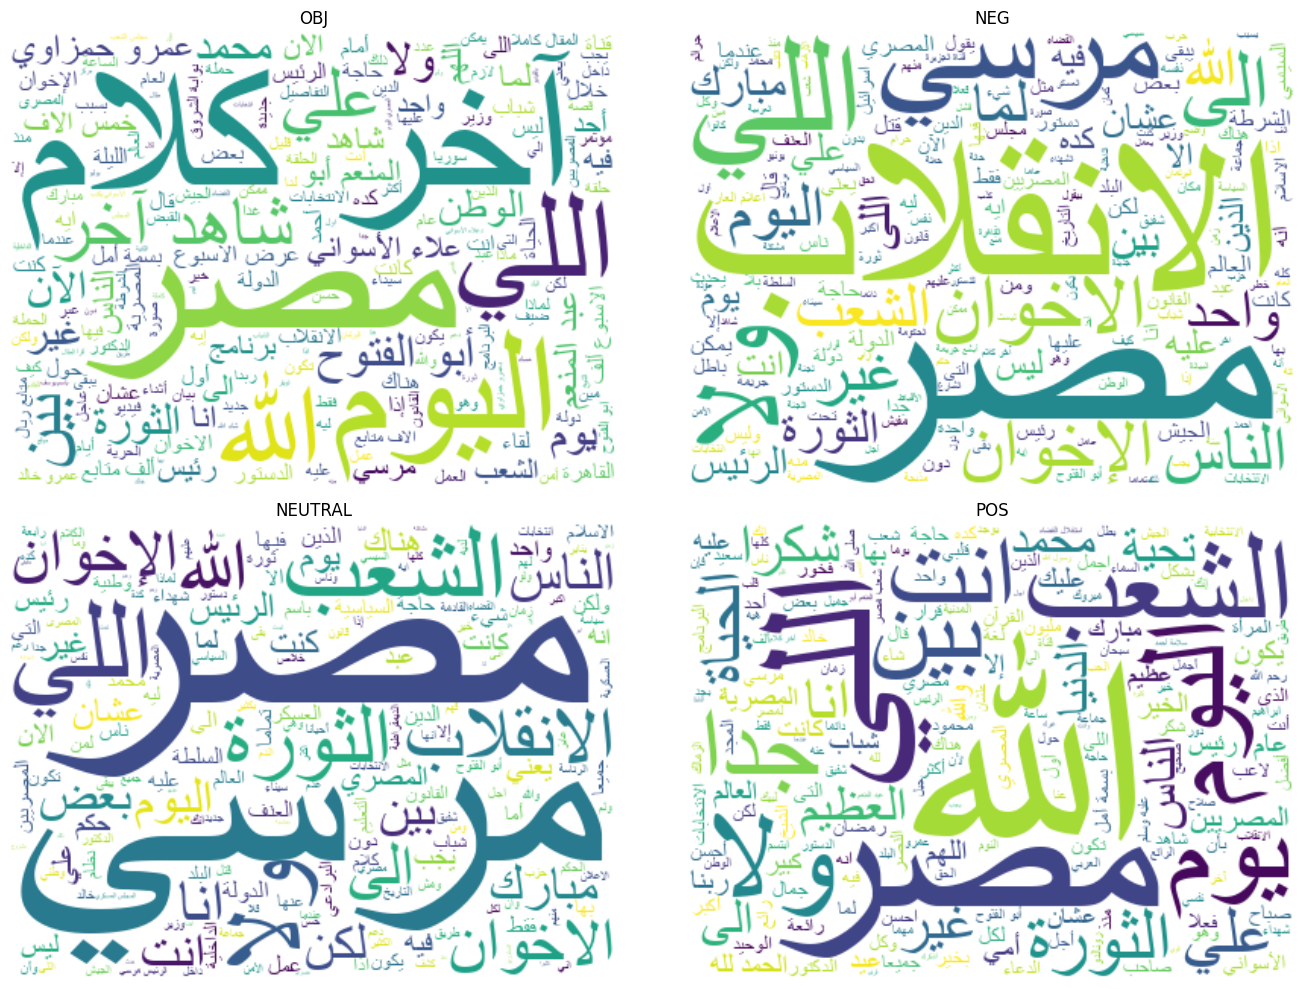

In [28]:
from wordcloud import WordCloud
import arabic_reshaper
from bidi.algorithm import get_display
import matplotlib.pyplot as plt

# حمّلي خط عربي - استخدمي أي خط موجود على ويندوز
font_path = r"C:\Windows\Fonts\arial.ttf"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, label in zip(axes.flatten(), ["OBJ", "NEG", "NEUTRAL", "POS"]):
    words = []
    for tweet in df[df["Label"] == label]["Tweet"]:
        words.extend(clean_text(tweet))
    text = " ".join(words)
    reshaped = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)
    
    wc = WordCloud(
        font_path=font_path,  # ← هذا هو الحل
        width=400, height=300,
        background_color="white"
    ).generate(bidi_text)
    
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()


In [29]:
import re

def clean_arabic(text):
    text = str(text)
    text = re.sub(r"http\S+", " ", text)        # روابط
    text = re.sub(r"@\S+", " ", text)           # منشنز
    text = re.sub(r"#", " ", text)              # رمز الهاشتاق بس
    text = re.sub(r"[إأآا]", "ا", text)         # توحيد الألف
    text = re.sub(r"ة", "ه", text)              # توحيد التاء المربوطة
    text = re.sub(r"ى", "ي", text)              # توحيد الياء
    text = re.sub(r"[\u064B-\u065F]", "", text) # إزالة التشكيل
    text = re.sub(r"[^\w\s]", " ", text)        # علامات الترقيم
    text = re.sub(r"[a-zA-Z0-9]", " ", text)   # إنجليزي وأرقام
    text = re.sub(r"\s+", " ", text).strip()    # مسافات زيادة
    return text

df["clean_tweet"] = df["Tweet"].apply(clean_arabic)
df[["Tweet", "clean_tweet"]].head(5)



,Tweet,clean_tweet
0,#الرياض #أمطار_الرياض #السعودية #مطر #الرياض_ت...,الرياض امطار_الرياض السعوديه مطر الرياض_تغرق ا...
1,من بين الأسماء محمود القرش، مصر الجديدة وآخرين...,من بين الاسماء محمود القرش مصر الجديده واخرين ...
2,مقتل طفلة لبنانية في تبادل إطلاق نار بين علويي...,مقتل طفله لبنانيه في تبادل اطلاق نار بين علويي...
3,#الروح_و_الجسد #مصطفي_محمود,الروح_و_الجسد مصطفي_محمود
4,دعبد المنعم أبو الفتوح فى عيون العالم,دعبد المنعم ابو الفتوح في عيون العالم
